В этом блокноте представлены команды для обучения нейросетей. Само обучение производилось на удаленном сервере с GPU (A5000 24 GB). Этап обучения реализован вне .ipynb - запуск производился в Docker-контейнерах с использованием базового образа Ultralytics



Примеры команд:

In [ ]:
#Обучение на rgb изображениях
!docker run -d --name yolo26_rgb_train --gpus all --ipc=host \
  -v /root/defects_detection_project/generated_datasets/defects_rgb_det:/dataset \
  -v /root/defects_detection_project/yolo_runs/defects_rgb_yolo26:/runs \
  ultralytics/ultralytics:latest \
  yolo detect train model=yolo26n.pt data=/dataset/data.yaml imgsz=640 epochs=100 patience=10 plots=True project=/runs name=train

#Обучение на rgb-d изображениях
!chmod +x utils/docker_train_rgbd_y26_gpu.sh && PROJECT=/root/defects_detection_project bash utils/docker_train_rgbd_y26_gpu.sh

Пример кода для обучения модели детектировать объекты на rgb-d изображениях через блокнот:

In [1]:
!source .venv/bin/activate && python --version && pip --version

Python 3.13.5
pip 25.1.1 from /home/vladimir/Документы/Проекты/Личные/defects_detection/.venv/lib/python3.13/site-packages/pip (python 3.13)


In [4]:
!pip install -r requirements.txt

  Using cached torch-2.11.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached cuda_bindings-13.2.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.3 kB)
  Using cached nvidia_cudnn_cu13-9.19.0.56-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.0-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.28.9-py3-none-manylinux_2_18_x86_64.whl.metadata (2.0 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-no

In [12]:
from pathlib import Path
import subprocess
import sys
import tempfile

from ultralytics import YOLO

proj = Path('.').resolve()
script = proj / 'utils' / 'train_rgbd_4ch_yolo.py'
data_yaml = proj / 'two_base_datasets (example)' / 'defects_rgbd_4ch_det' / 'data.yaml'
run_name = 'yolo26n_rgbd4ch_1epoch'

with tempfile.TemporaryDirectory() as tmp:
    project_dir = Path(tmp)
    subprocess.run(
        [
            sys.executable,
            str(script),
            '--verify-loader-only',
            '--data',
            str(data_yaml),
            '--imgsz',
            '640',
        ],
        check=True,
    )
    subprocess.run(
        [
            sys.executable,
            str(script),
            '--data',
            str(data_yaml),
            '--model',
            'yolo26n.pt',
            '--epochs',
            '1',
            '--imgsz',
            '640',
            '--patience',
            '10',
            '--plots',
            '--project',
            str(project_dir),
            '--name',
            run_name,
        ],
        check=True,
    )
    best_pt = project_dir / run_name / 'weights' / 'best.pt'
    model = YOLO(str(best_pt))
    print('architecture (trained 1 epoch, weights from temp dir):')
    model.info(detailed=True, verbose=True, imgsz=640)




train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3912.4±397.6 MB/s, size: 13162.2 KB)
train: Scanning /home/vladimir/Документы/Проекты/Личные/defects_detection/two_base_datasets (example)/defects_rgbd_4ch_det/train/labels.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 11.6Mit/s 0.0s
[verify-loader] первый образ: shape=torch.Size([4, 640, 640])
[verify-loader] OK - 4 входных канала в батче.
[rgbd-train] YOLO load: yolo26n.pt
[rgbd-train] model.train(...) start
Ultralytics 8.4.48 🚀 Python-3.13.5 torch-2.11.0+cu130 CPU (13th Gen Intel Core i5-13420H)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/vladimir/Документы/Проекты/Личные/defects_detection/two_base_datasets (example)/defects_rgbd_4ch_det/data.yaml, degrees

Объяснение:

Ячейка выше запускает utils/train_rgbd_4ch_yolo.py. В нём перед обучением вызывается apply_ultralytics_4channel_loader_patch - оборачивается конструктор ultralytics.data.base.BaseDataset. После обычной инициализации, если у датасета в поле channels число не равно 1 и не равно 3 (в нашем случае из data.yaml передано четыре канала), для чтения файлов задаётся флаг OpenCV IMREAD_UNCHANGED. По умолчанию Ultralytics читает изображения как трёхканальные цветные, и четвёртый канал из PNG отбрасывается; с IMREAD_UNCHANGED из файла поднимаются все каналы подряд, поэтому на вход модели попадает тензор вида 4 канала на высоту и ширину. Датасет уже собран как четырёхканальные PNG (RGB + один канал глубины в одном файле), а в data.yaml указано 4 входных канала.

Дальше либо только проверяется первый батч на число каналов (режим verify-loader-only), либо запускается стандартное model.train от Ultralytics с тем же патчем - короткий прогон обучения, результаты в временной папке, затем загрузка сохранённых весов и вывод подробного описания архитектуры через model.info с параметром detailed.


Это был пример запуска обучения на демонстрационном датасете. Далее приведены результаты после обучения на рабочих датасетах

Кривые обучения и метрики по эпохам

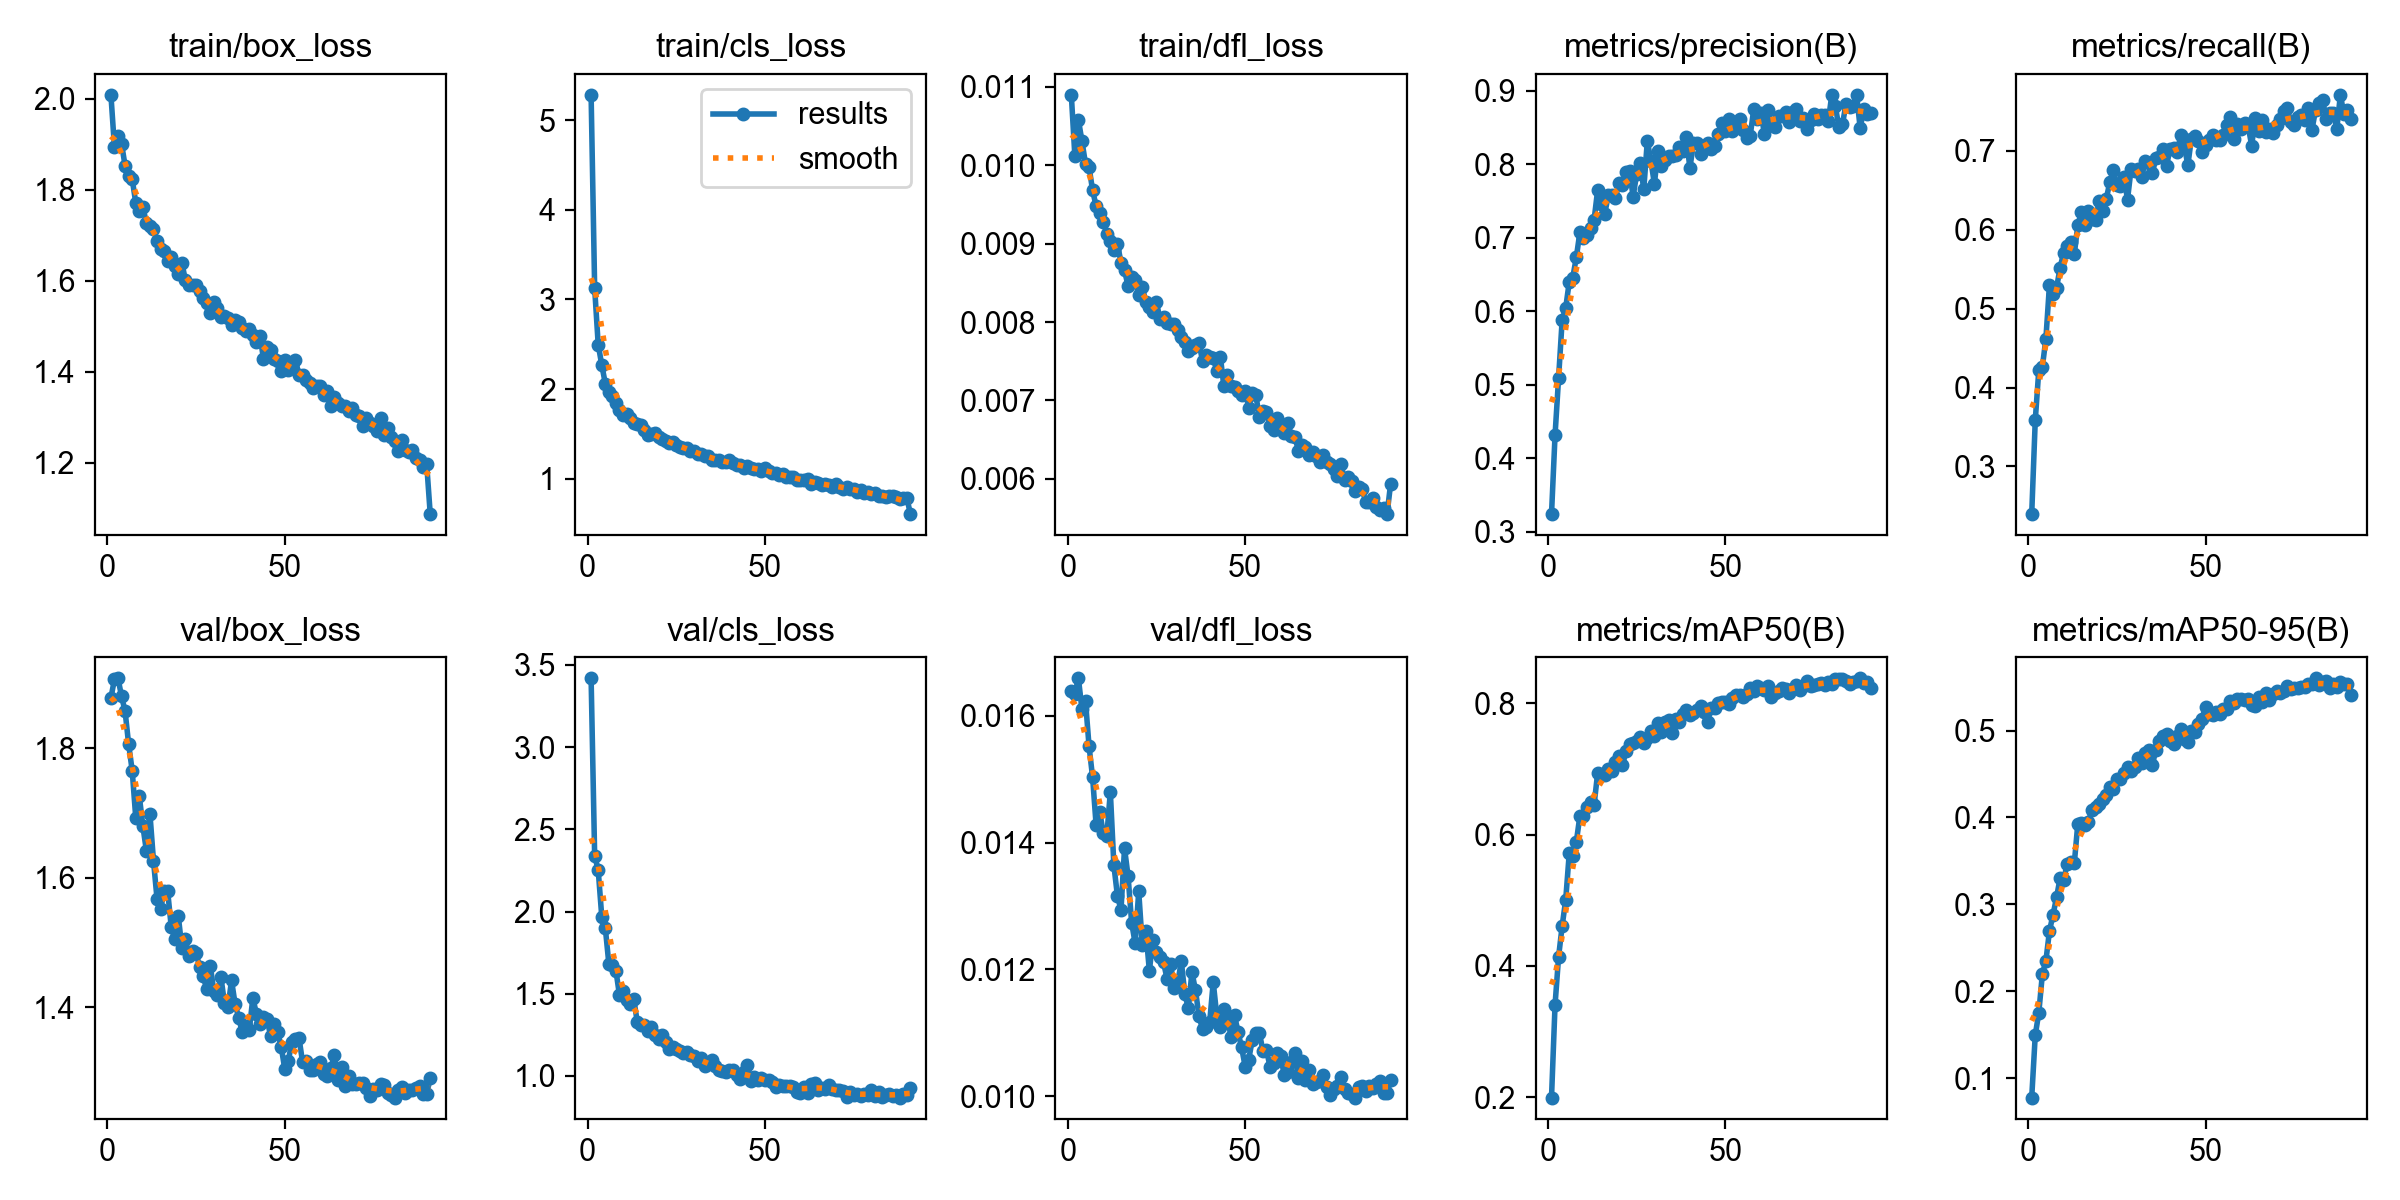

Precision-Recall по боксам

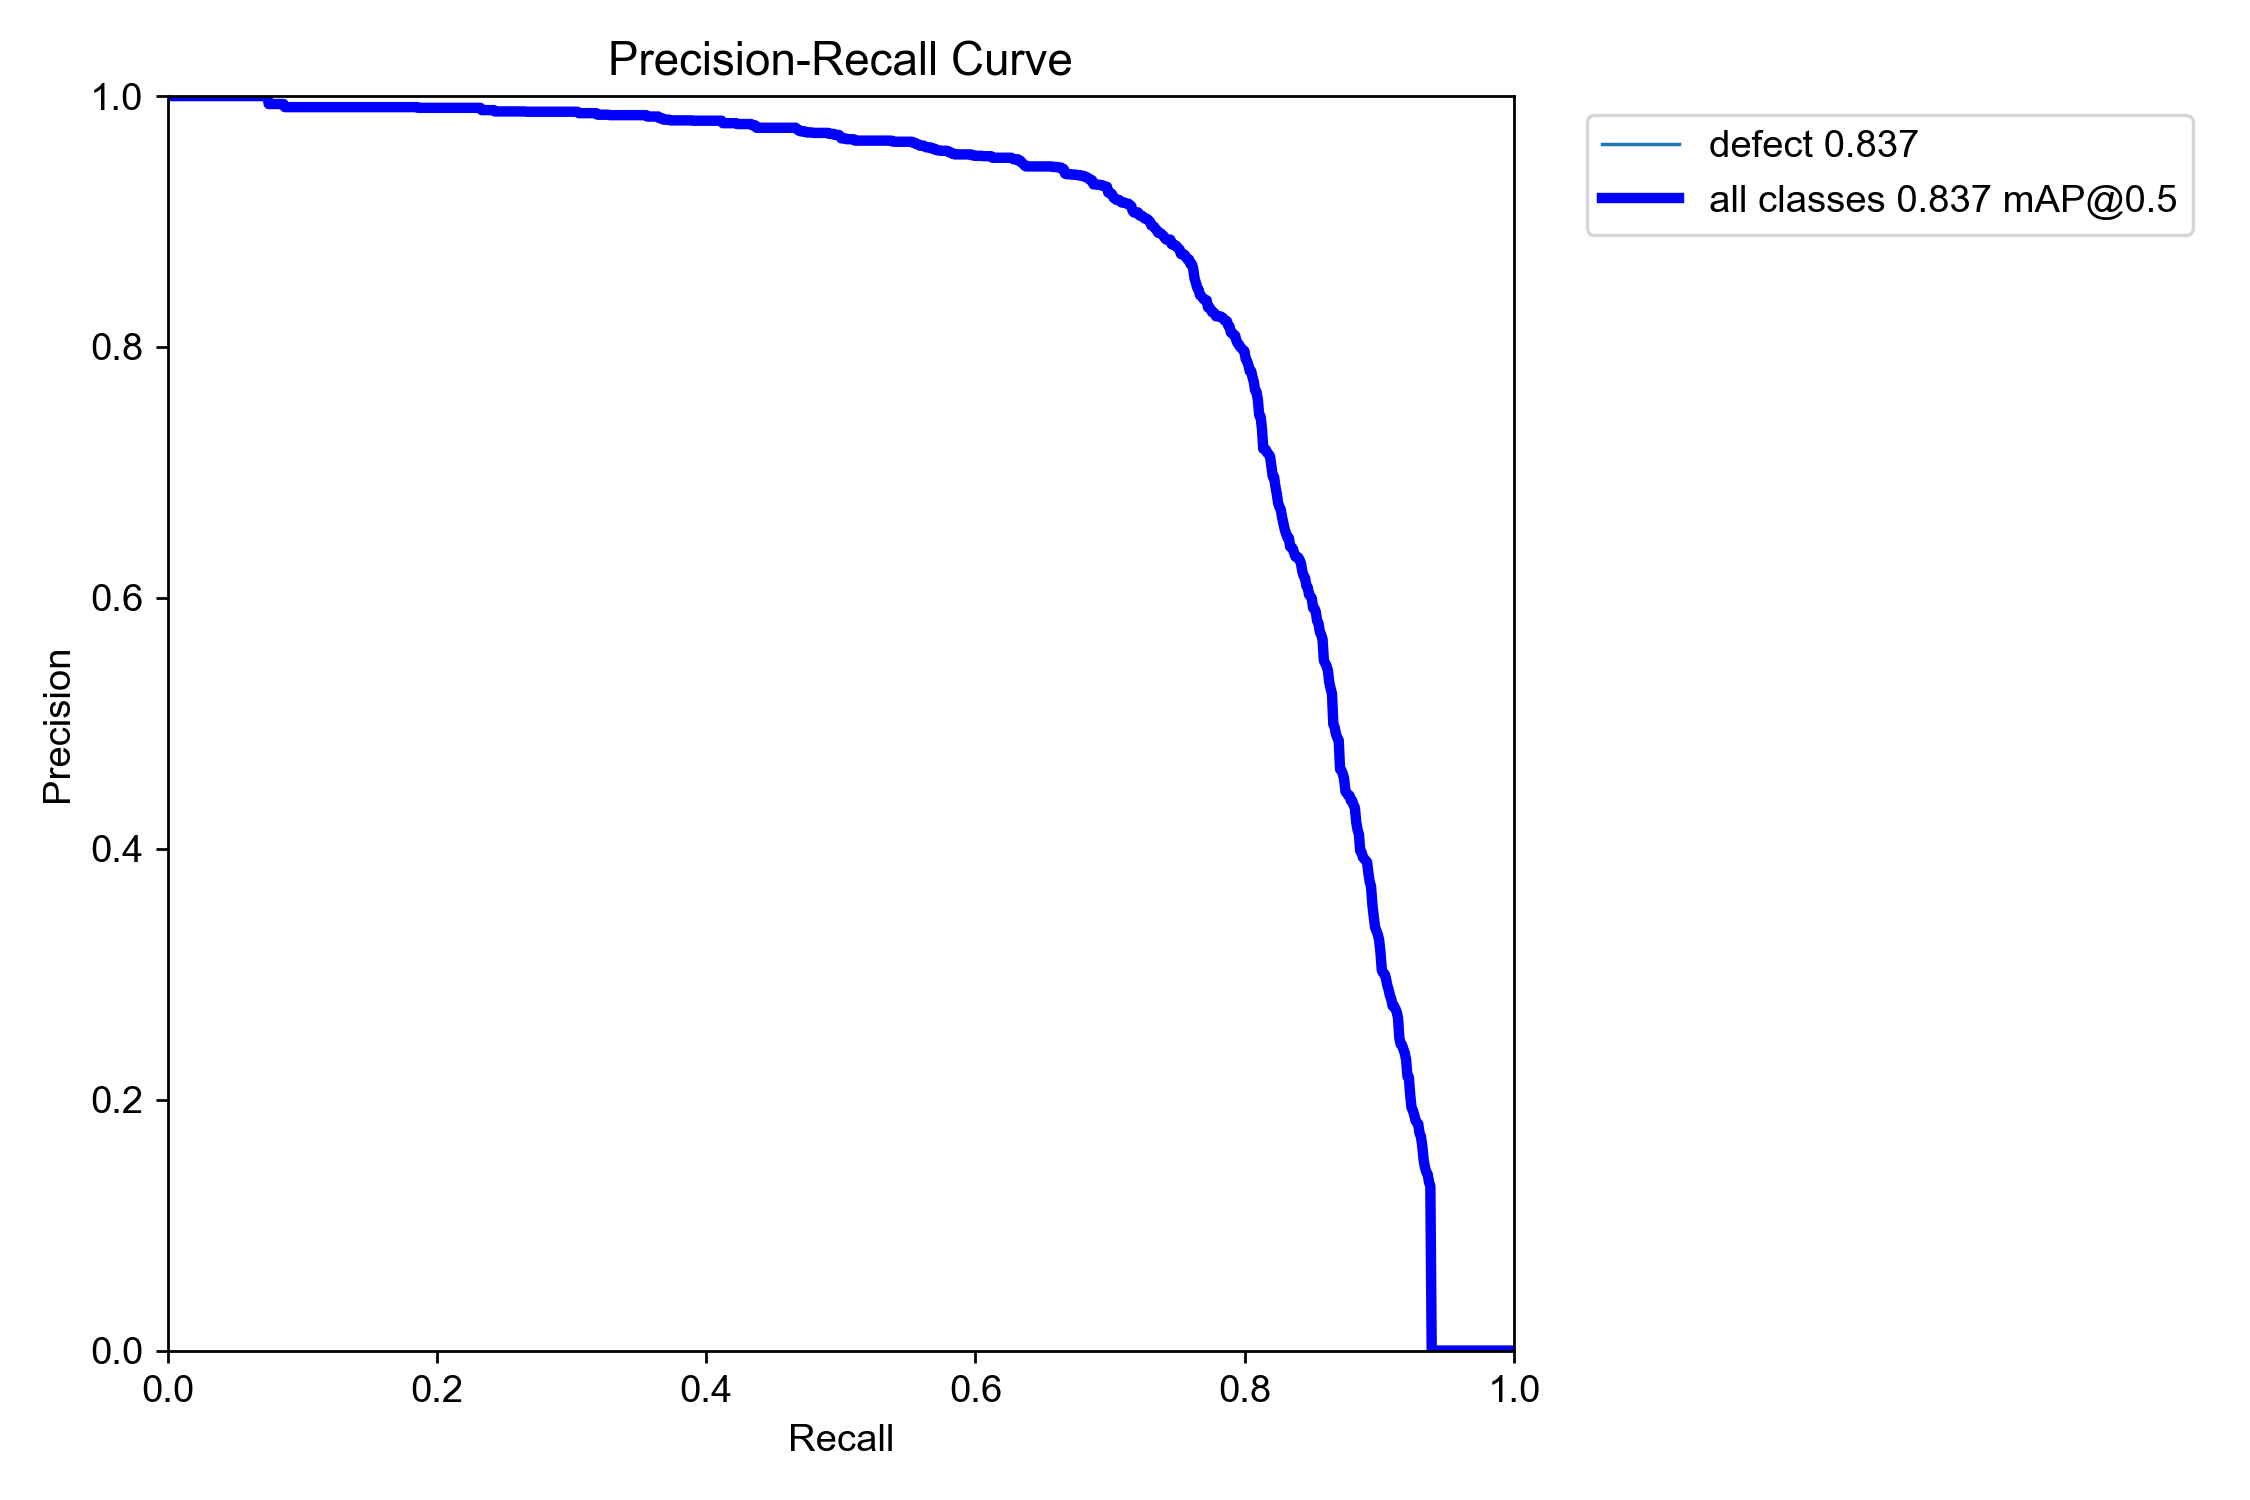

Валидация, разметка

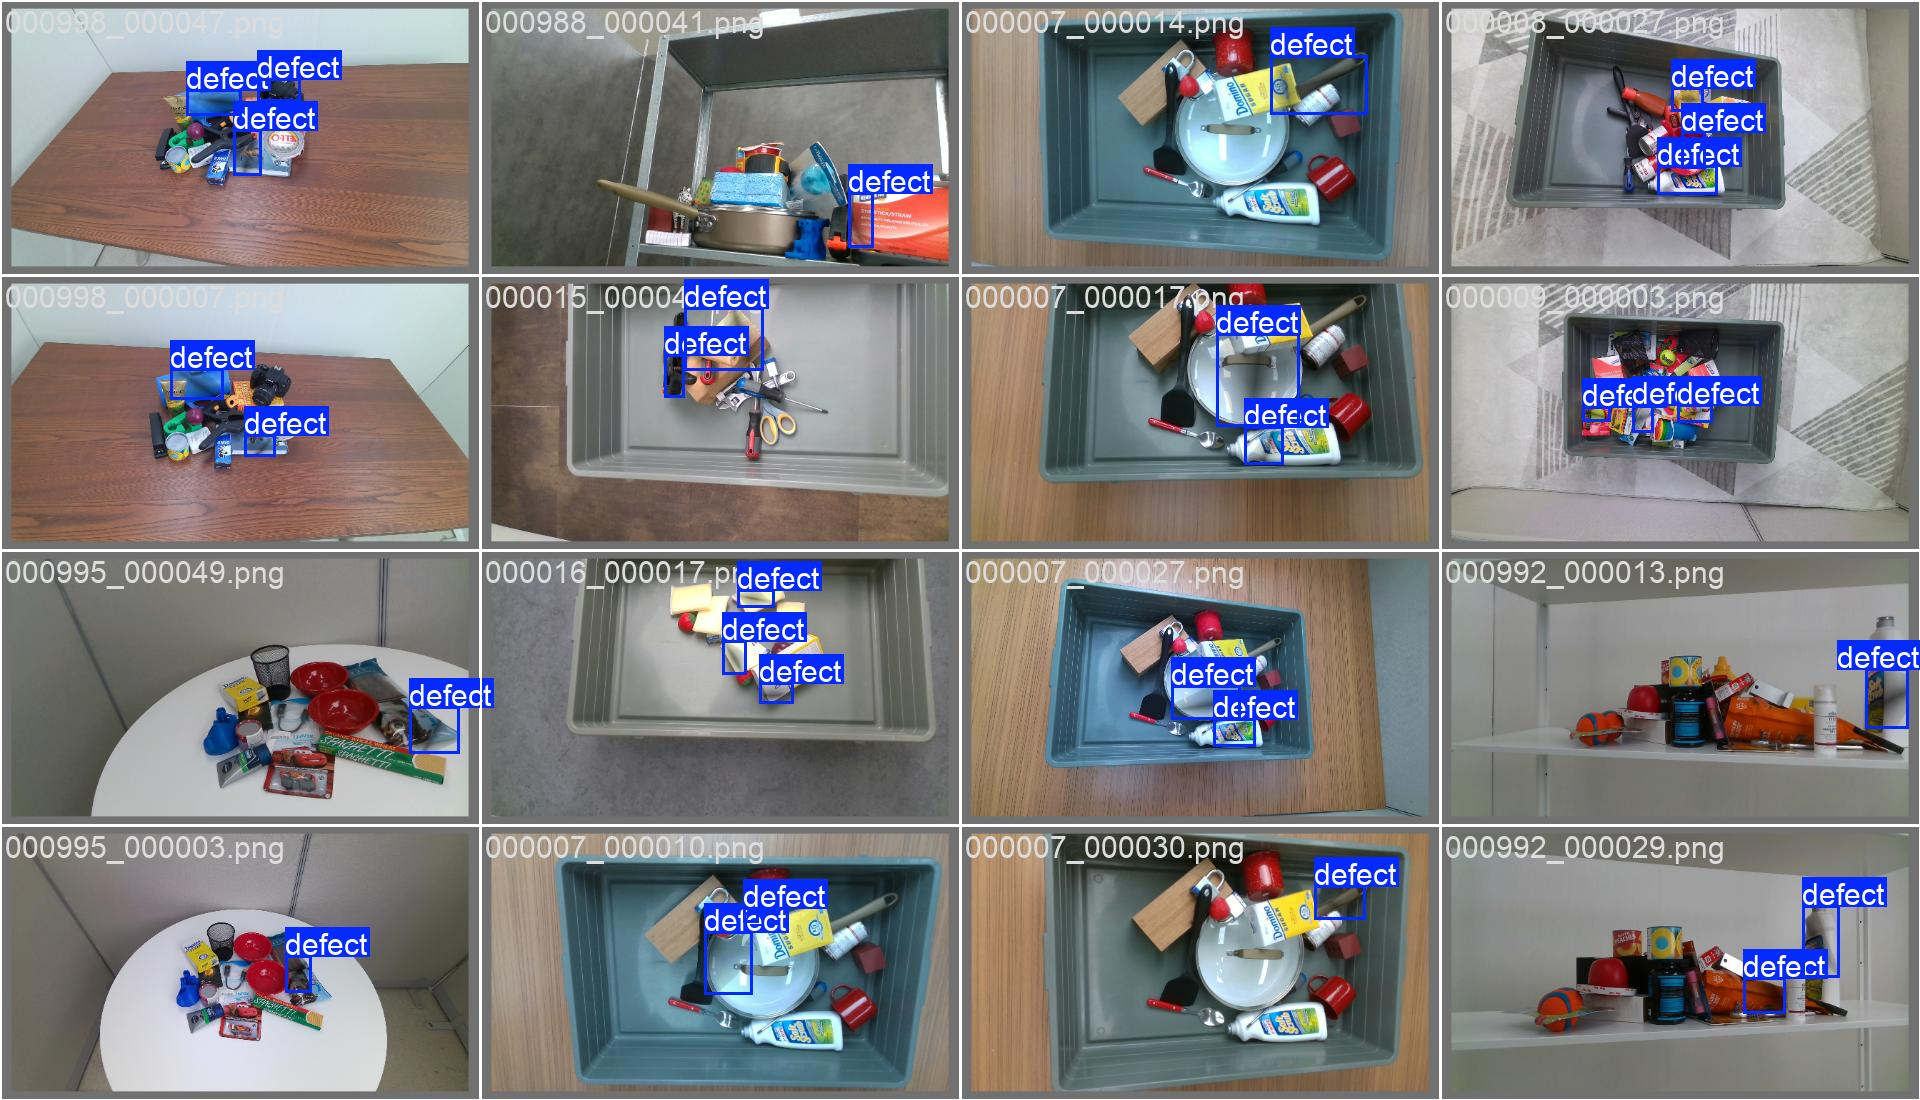

Валидация, предсказания

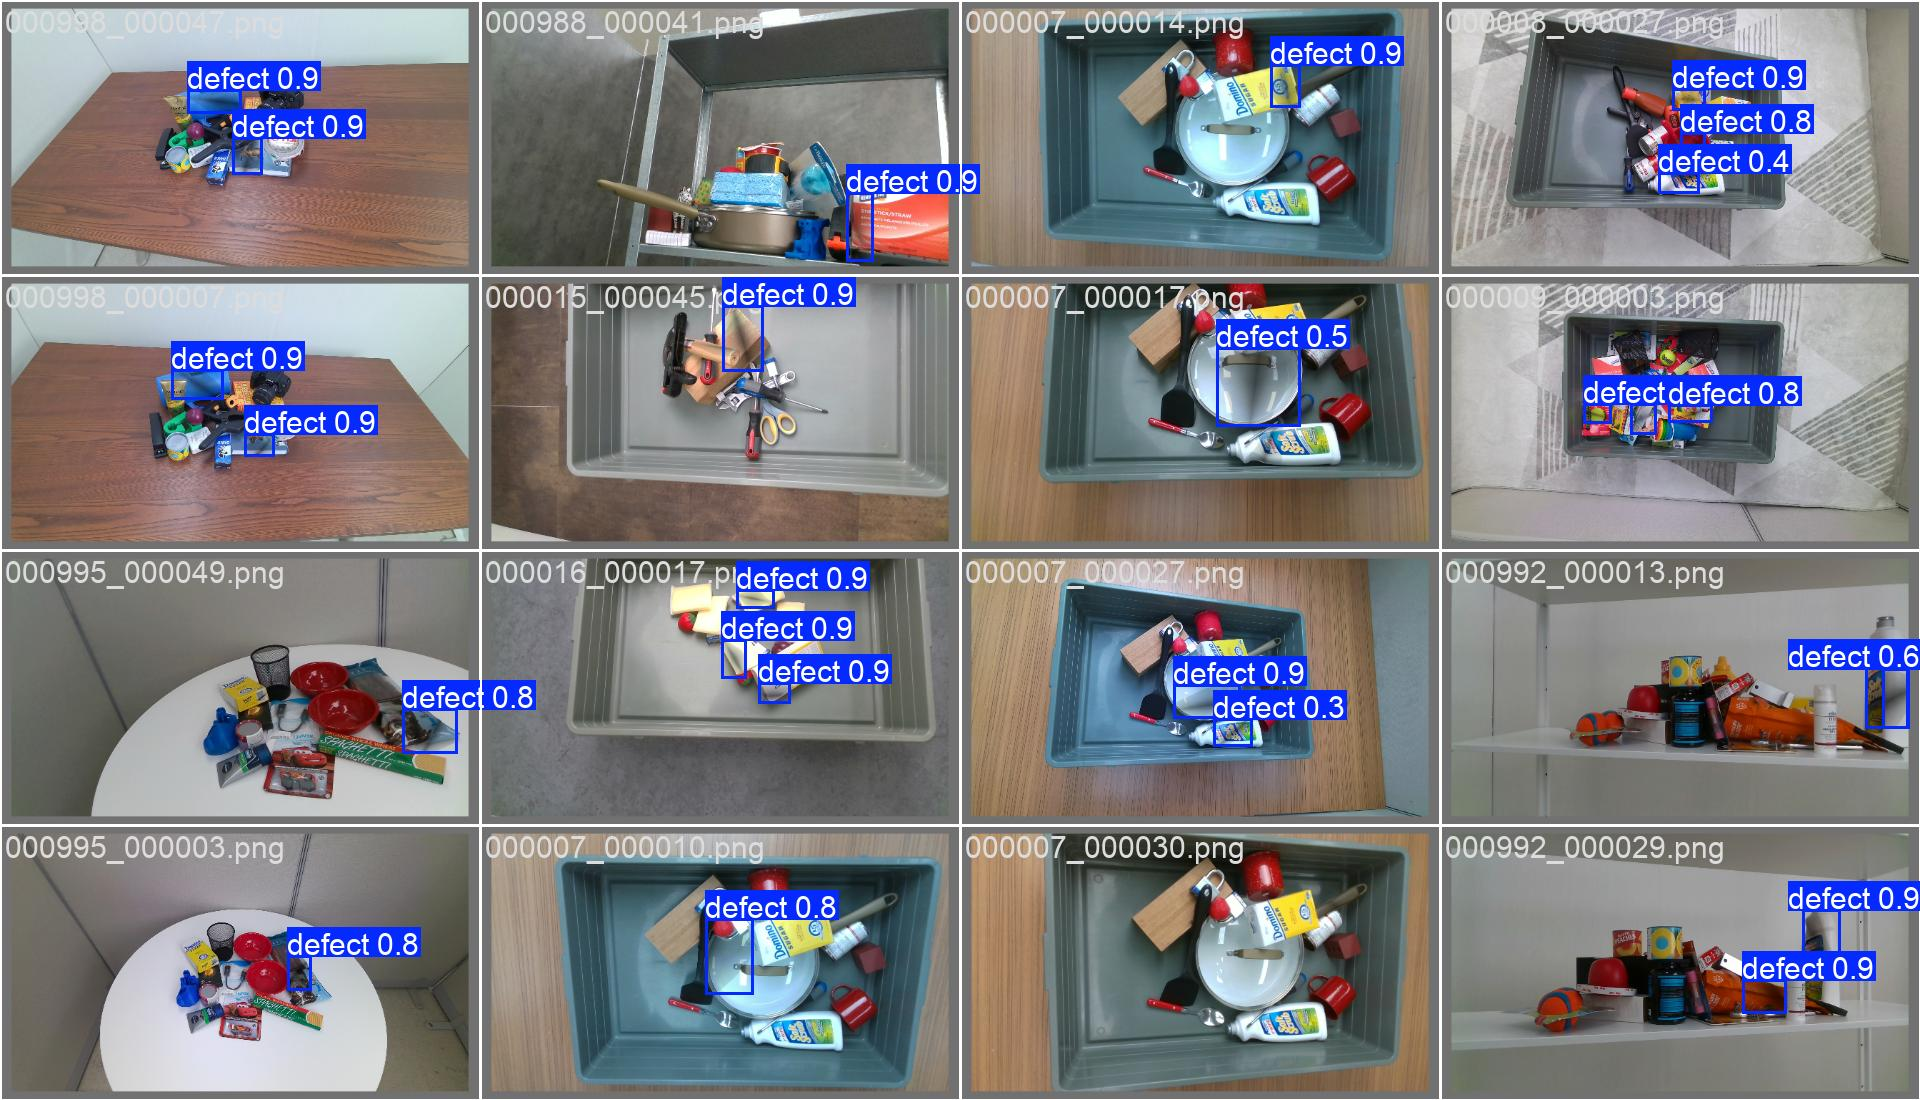

In [13]:
# Обучение на датасете с RGB изображениями
from pathlib import Path

from IPython.display import Image, Markdown, display

proj = Path(".").resolve()
run_dir = proj / "train_and_test_results/defects_rgb_det/defects_rgb_y26n640"

files = [
    ("Кривые обучения и метрики по эпохам", run_dir / "results.png"),
    ("Precision-Recall по боксам", run_dir / "BoxPR_curve.png"),
    ("Валидация, разметка", run_dir / "val_batch0_labels.jpg"),
    ("Валидация, предсказания", run_dir / "val_batch0_pred.jpg"),
]

for title, path in files:
    display(Markdown(title))
    if path.is_file():
        display(Image(filename=str(path)))
    else:
        print("Файл не найден:", path)


Результаты обучения RGB (YOLO26n, датасет defects_rgb_det, imgsz 640, до 100 эпох с patience 10 на сервере с GPU). Обучение остановилось на эпохе 91, лучшие веса по валидации на эпохе 81. На лучшей эпохе по valid получены примерно следующие метрики по боксам: precision около 0.88, recall около 0.75, mAP50 около 0.84, mAP50-95 около 0.56. На тестовом сплите: precision около 0.865, recall около 0.769, mAP50 около 0.841, mAP50-95 около 0.567. Графики выше показывают динамику лоссов и метрик по эпохам, кривую PR и примеры батча валидации с разметкой и с предсказанными боксами


Обучение на датасете RGB-D (четыре канала в одном PNG, defects_rgbd_4ch_det).


Кривые обучения и метрики по эпохам

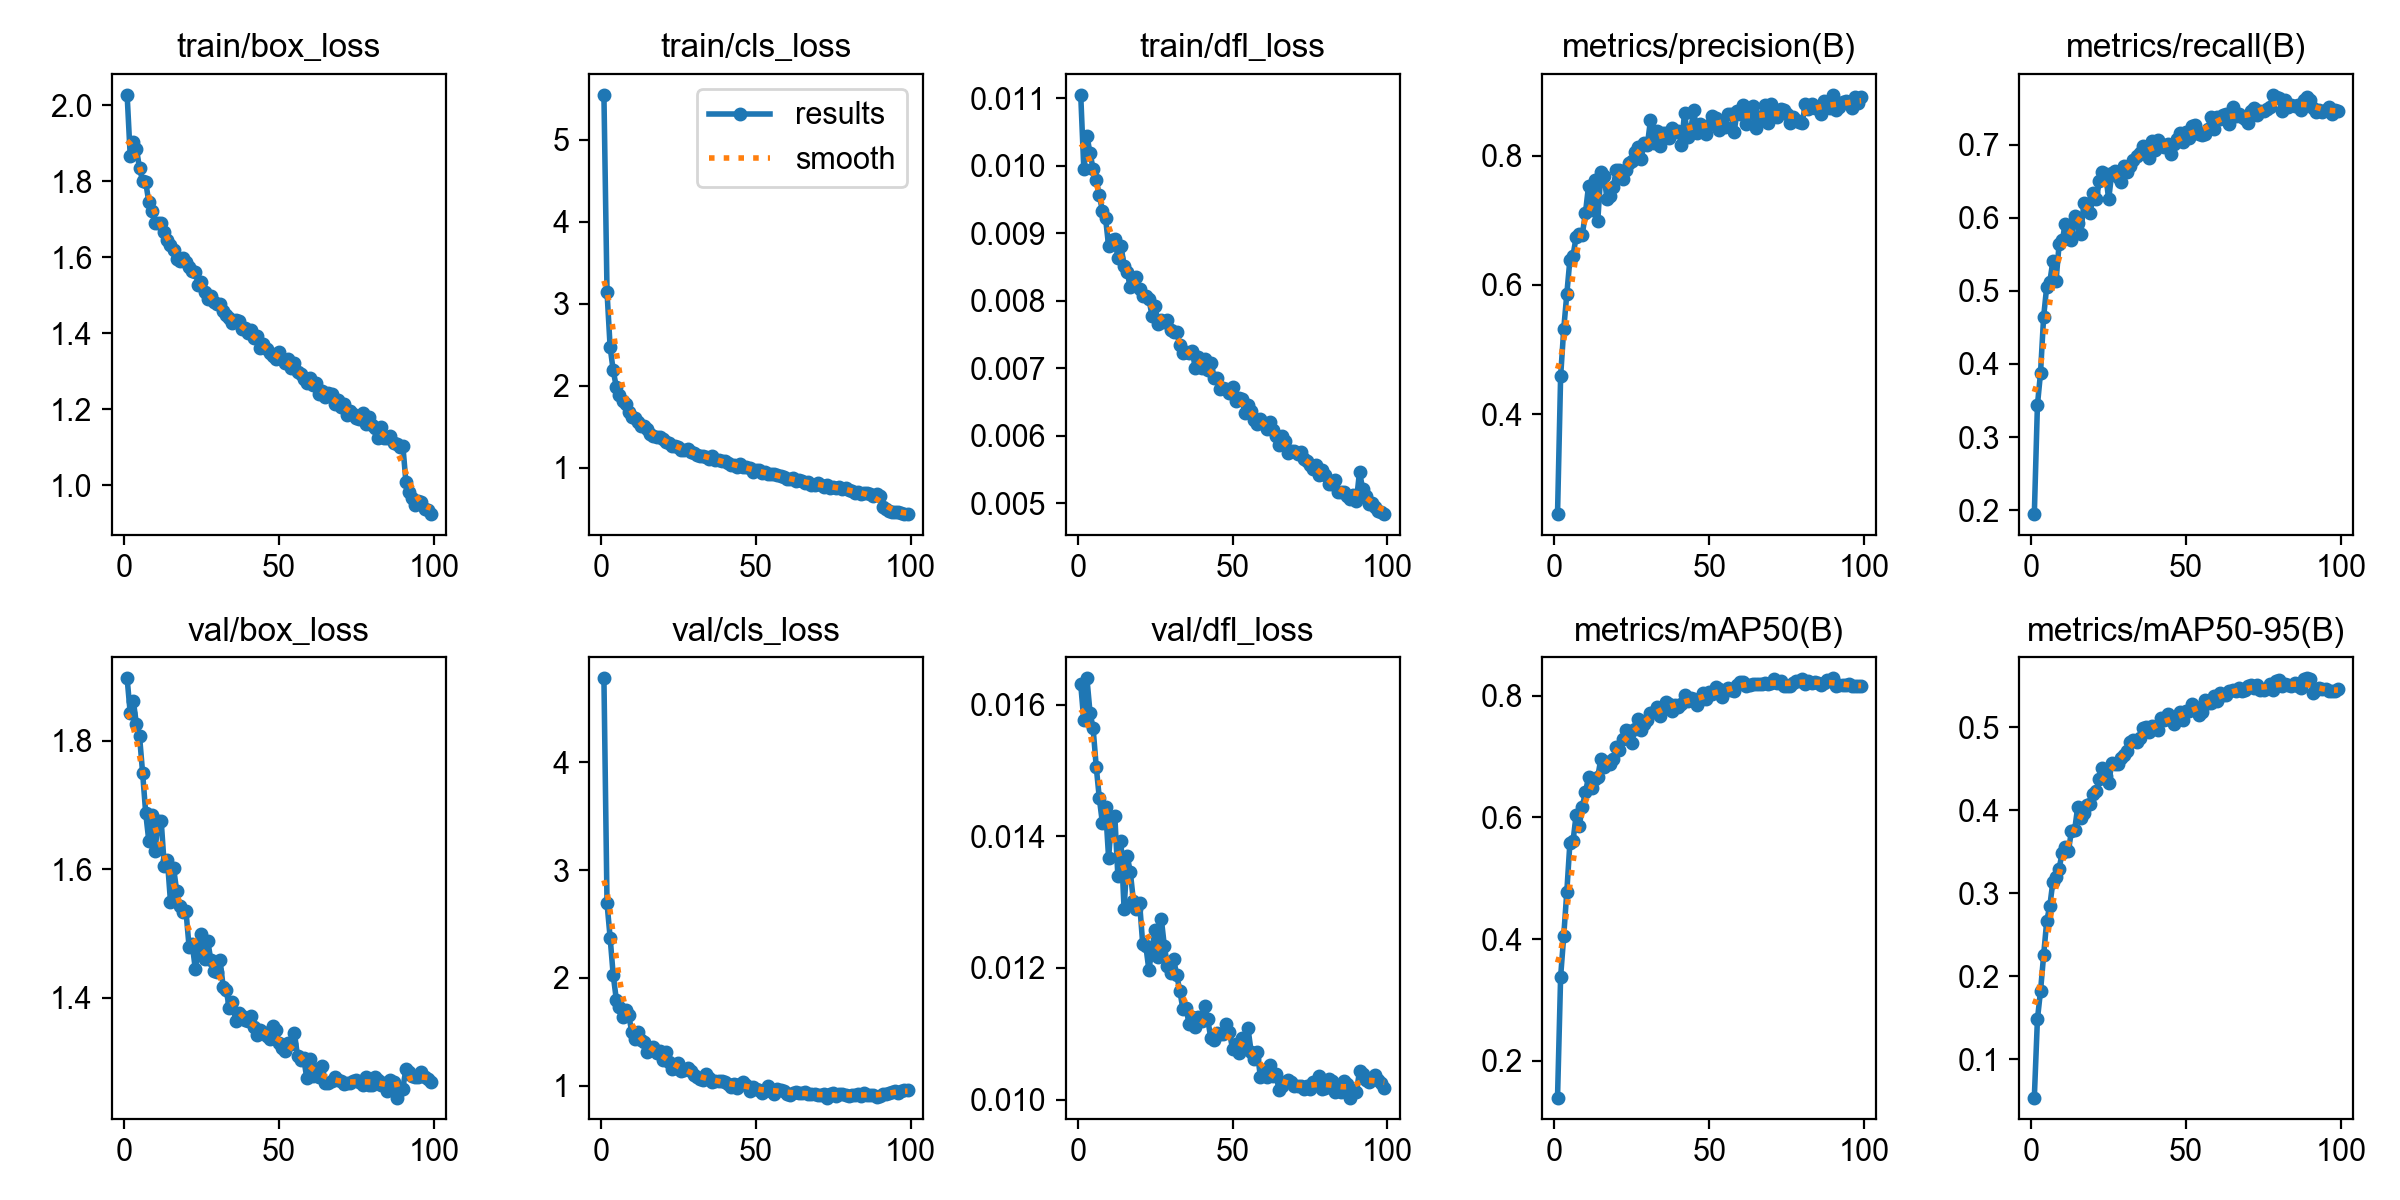

Precision-Recall по боксам

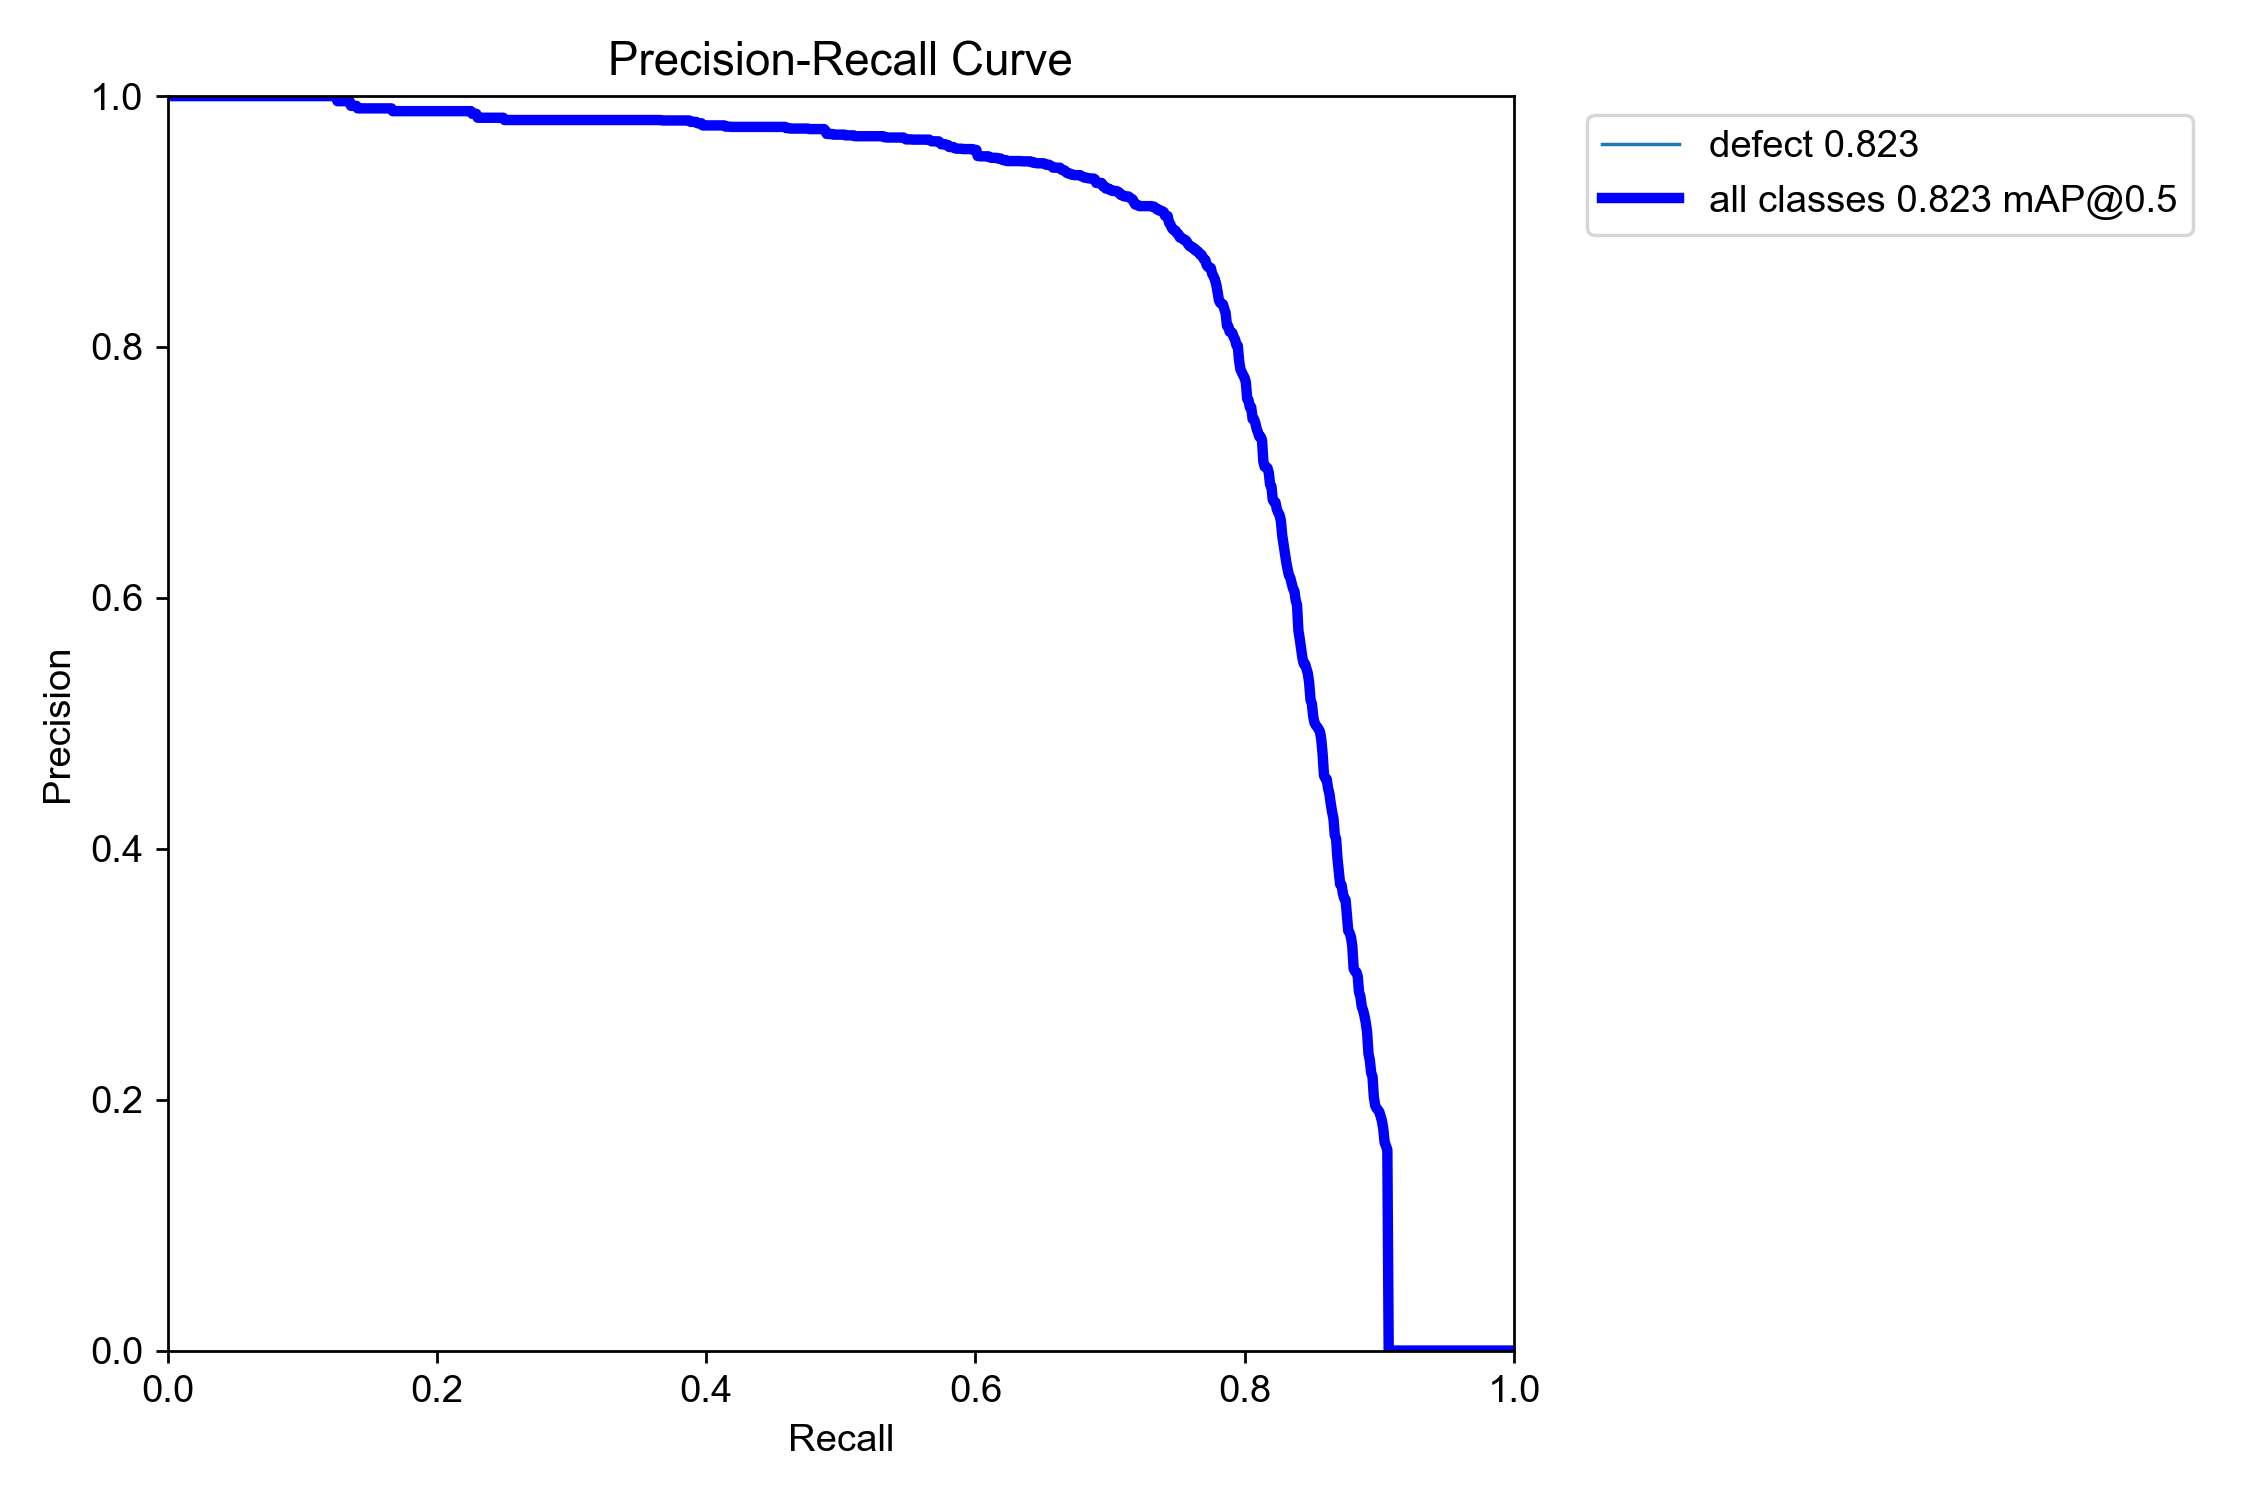

Валидация, разметка

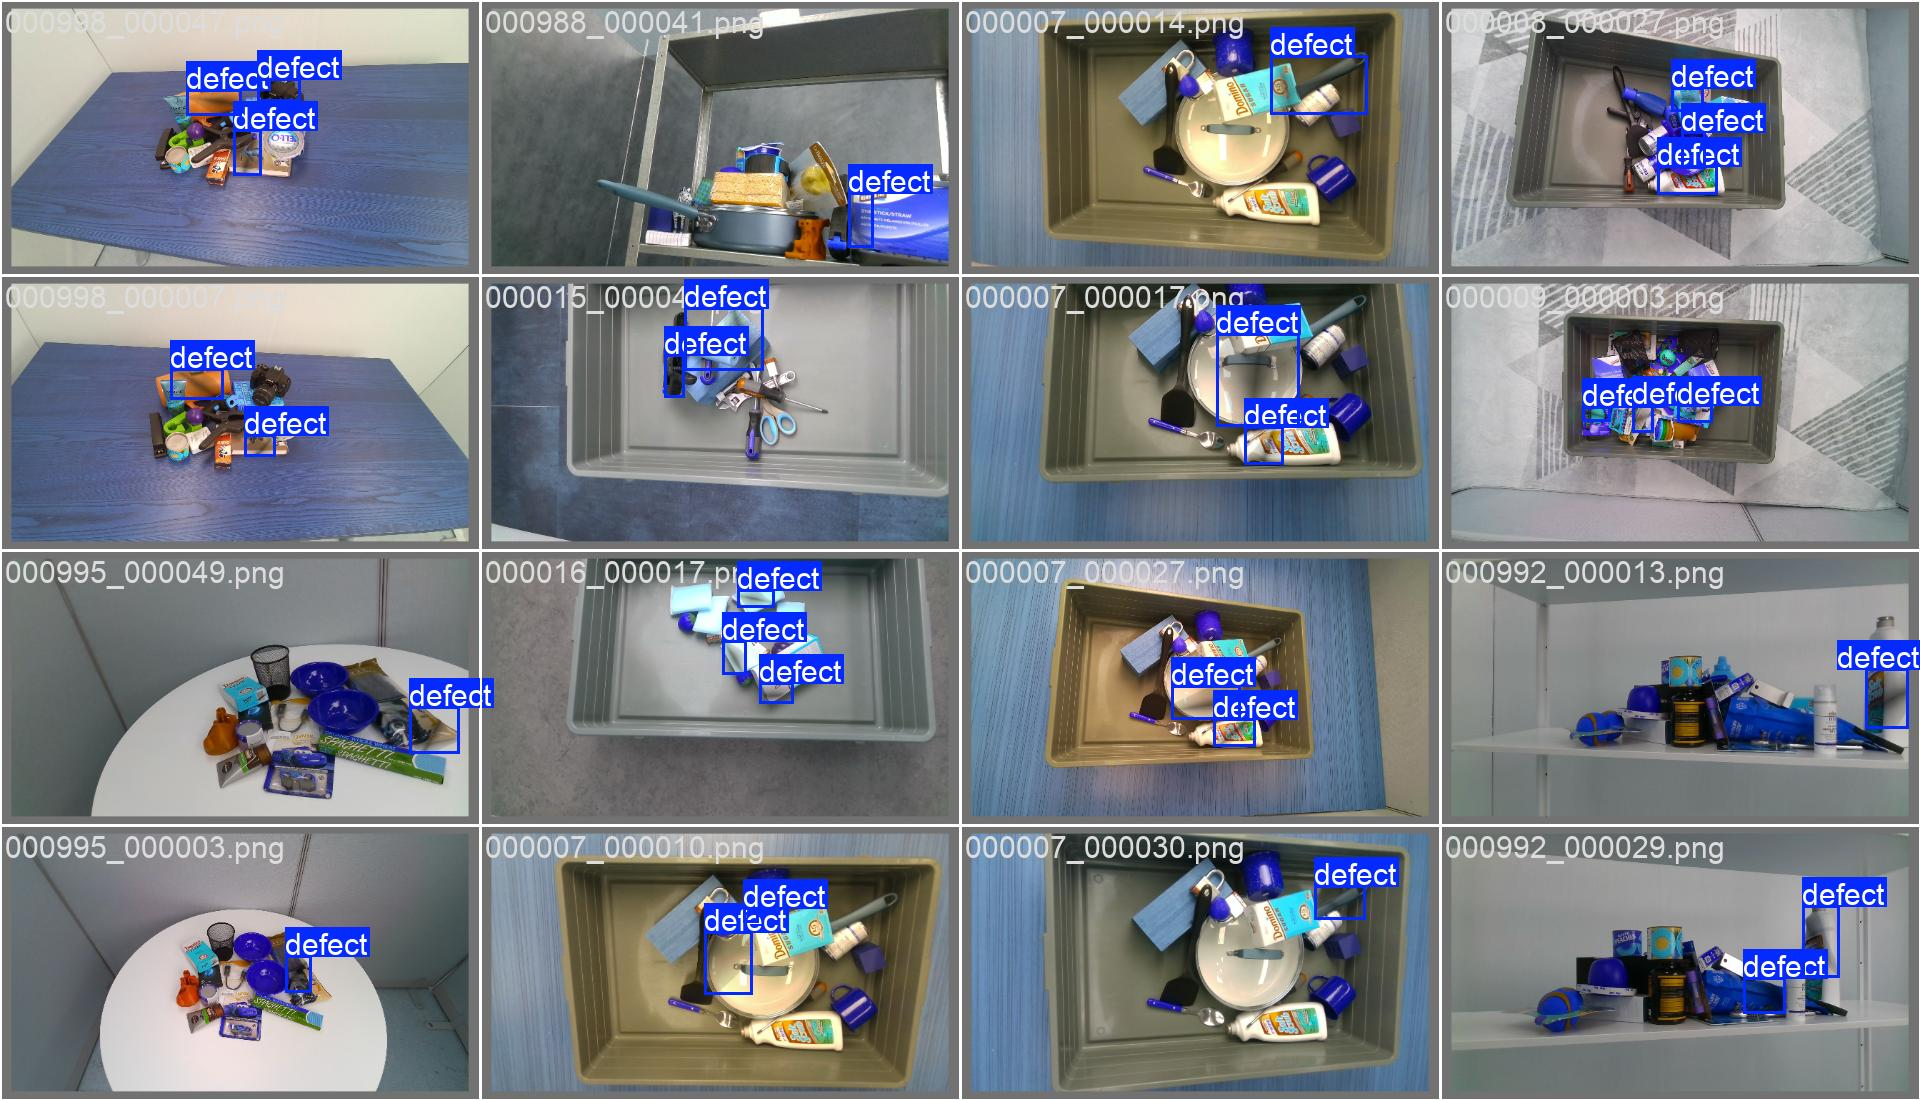

Валидация, предсказания

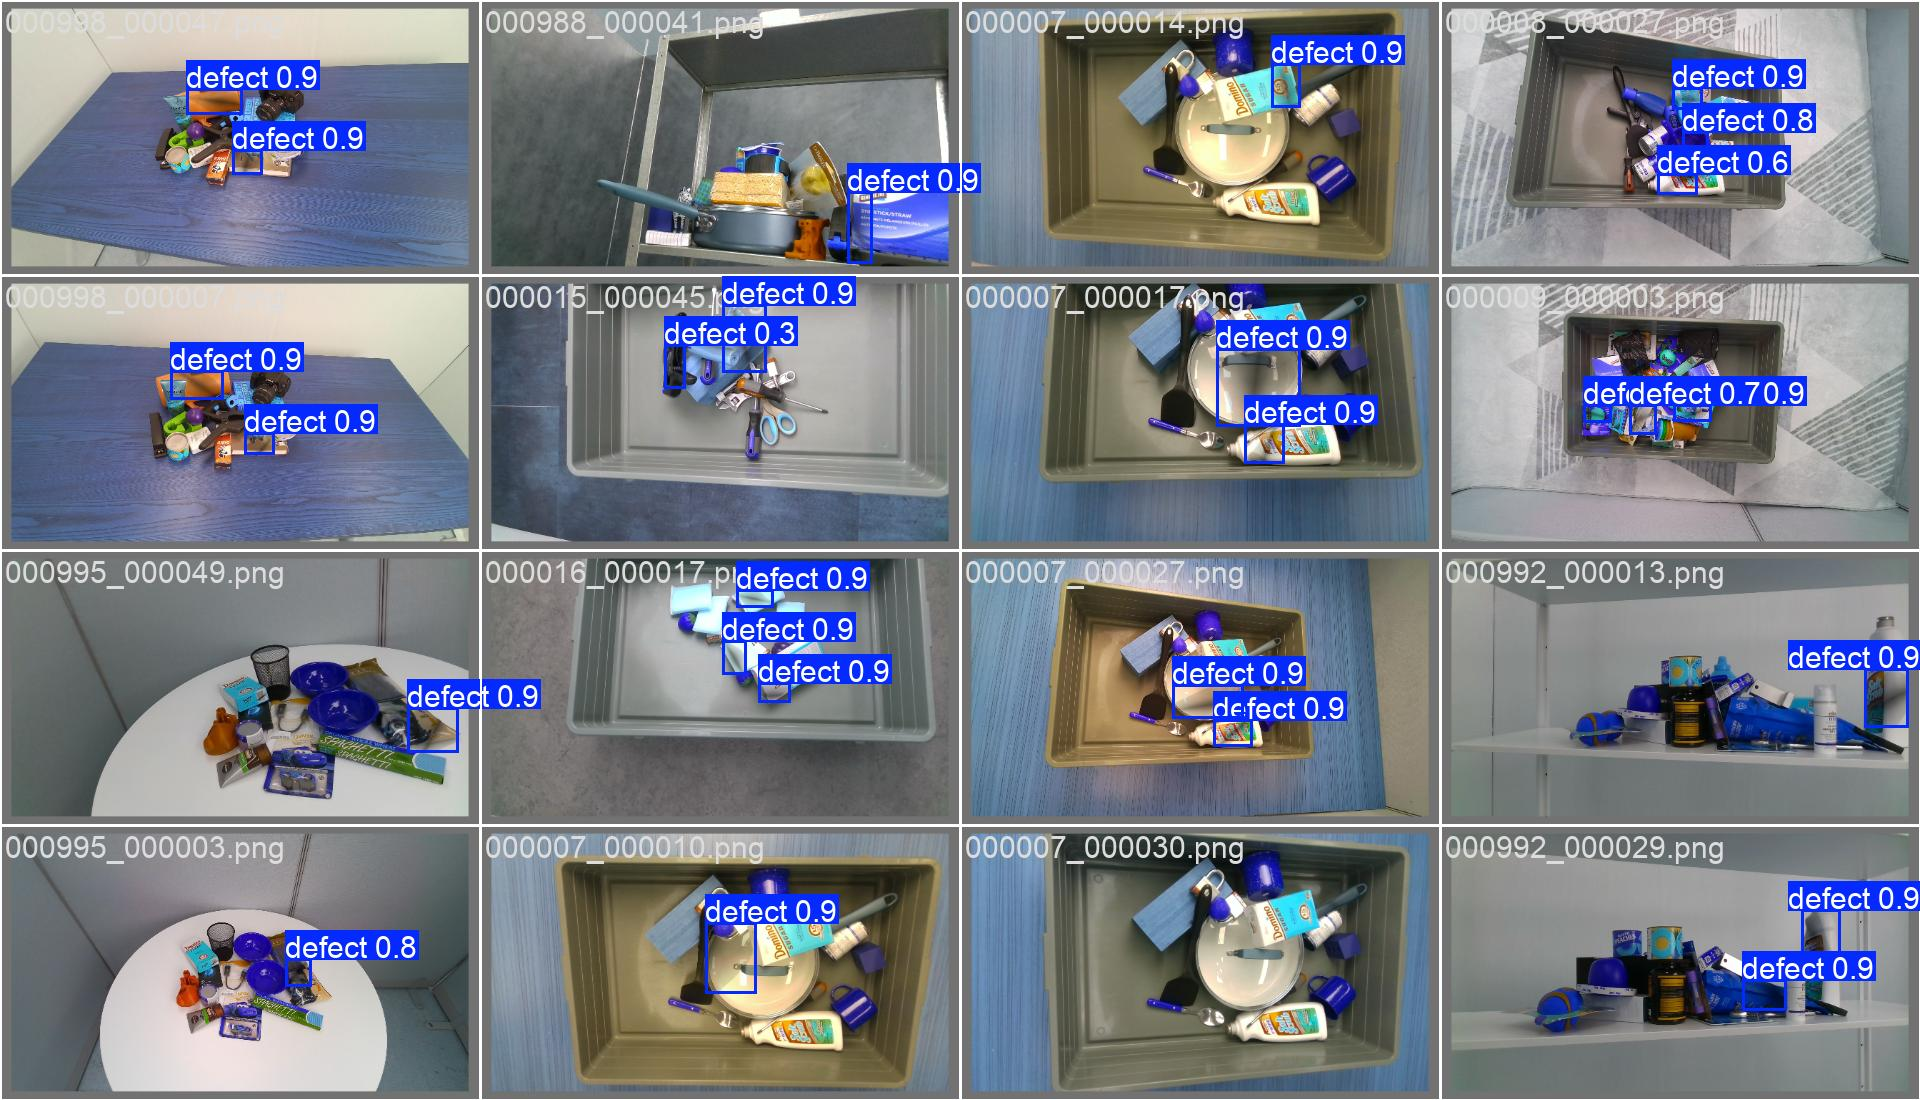

In [14]:
# Обучение RGB-D, четыре канала
from pathlib import Path

from IPython.display import Image, Markdown, display

proj = Path(".").resolve()
run_dir = proj / "train_and_test_results/defects_rgbd_4ch_det/defects_rgbd_y26n640"

files = [
    ("Кривые обучения и метрики по эпохам", run_dir / "results.png"),
    ("Precision-Recall по боксам", run_dir / "BoxPR_curve.png"),
    ("Валидация, разметка", run_dir / "val_batch0_labels.jpg"),
    ("Валидация, предсказания", run_dir / "val_batch0_pred.jpg"),
]

for title, path in files:
    display(Markdown(title))
    if path.is_file():
        display(Image(filename=str(path)))
    else:
        print("Файл не найден:", path)


Результаты обучения RGB-D с четырьмя входными каналами (YOLO26n, датасет defects_rgbd_4ch_det, imgsz 640, те же настройки эпох и ранней остановки на сервере с GPU). Обучение завершилось на эпохе 99, лучшие веса по валидации на эпохе 89. На лучшей эпохе по valid примерные значения: precision 0.87, recall 0.76, mAP50 0.82, mAP50-95 0.56. На тестовом сплите: precision около 0.862, recall около 0.798, mAP50 около 0.846, mAP50-95 около 0.576. По тесту recall и mAP50-95 выше, чем у отдельной RGB-модели при той же разметке
